<h1 style="text-align:center; font-size:40px;">
<span style="color:#4285F4;">G</span>
<span style="color:#DB4437;">o</span>
<span style="color:#F4B400;">o</span>
<span style="color:#4285F4;">g</span>
<span style="color:#0F9D58;">l</span>
<span style="color:#DB4437;">e</span>
<span style="color:black;">Ads Sale DataAnalytics</span>
</h1>

<h3 style="color:red; font-size:24px;">Aim</h3>

In [ ]:


##Project Objectives:

         The objective of this project to analyze the GoogleADS sale dataset using python and perform exploratory data  analysis(EDA).This project
aims to explore different adverstinig performance indicators such as Clicks,impressions,cost,leads,conversion,conversion rate,and sale amount across
different campaigns,keywords,locations and devices. Through exploratory data analysis ,the project will identify patterns,trends, and relationship
in digital marketing performance data.Data cleaning will perfomed to handle missing values,correct inconsistent column name ,and remove duplicate
record to ensure data quality.




#Data Loading and Initial Overview


<h3 style="color:red; font-size:px;">Importing libraries</h3>


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

<h3 style="color:red; font-size:24px;">Data Loading</h3>

In [6]:
df=pd.read_csv(r"C:\Users\MINU MUJSINA\Downloads\googleAds_sales_data.csv")

In [7]:
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,16-11-2024,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,16-11-2024,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,26-11-2024,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,22-11-2024,hyderabad,desktop,online data analytic


In [8]:
df.shape

(2600, 13)

In [5]:
df.columns

Index(['Ad_ID', 'Campaign_Name', 'Clicks', 'Impressions', 'Cost', 'Leads',
       'Conversions', 'Conversion Rate', 'Sale_Amount', 'Ad_Date', 'Location',
       'Device', 'Keyword'],
      dtype='object')

In [8]:
##Column description

1.Ad_ID - Unique ID of advertisement 2.Campaign_Name - Name of marketing campaign 3.Clicks -Number of users clicked 
4.Impressions - Number of times ad shown 5.Cost -Money spent on ads 6.Leads -Interested users 7.Conversions -Final actions
8.Conversion Rate -percentage of success 9.Sale_amount -Revenue generated 10.Ad_Date
11.Location -Users location 12.Device -Mobile/Desktop/Tablet 13.keyword -search keyword





In [9]:
df.shape

(2600, 13)

In [10]:
df.describe()

,Clicks,Impressions,Leads,Conversions,Conversion Rate
count,2488.000000,2546.000000,2552.000000,2526.000000,1974.000000
mean,138.956994,4523.280833,20.003918,6.519002,0.048979
std,34.619376,869.927913,6.032317,2.272573,0.019987
min,80.000000,3000.000000,10.000000,3.000000,0.015000
25%,110.000000,3764.000000,15.000000,5.000000,0.035000
50%,139.000000,4518.500000,20.000000,7.000000,0.046000
75%,169.000000,5279.500000,25.000000,9.000000,0.058000
max,199.000000,5999.000000,30.000000,10.000000,0.123000


<h3 style="color:red;font-size:24px;">Data Preprossing</h3>

In [11]:
df.isnull().sum()

Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions         74
Conversion Rate    626
Sale_Amount        139
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

In [10]:
#Fill Numeric columns

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   object 
 1   Campaign_Name    2600 non-null   object 
 2   Clicks           2488 non-null   float64
 3   Impressions      2546 non-null   float64
 4   Cost             2503 non-null   object 
 5   Leads            2552 non-null   float64
 6   Conversions      2526 non-null   float64
 7   Conversion Rate  1974 non-null   float64
 8   Sale_Amount      2461 non-null   object 
 9   Ad_Date          2600 non-null   object 
 10  Location         2600 non-null   object 
 11  Device           2600 non-null   object 
 12  Keyword          2600 non-null   object 
dtypes: float64(5), object(8)
memory usage: 264.2+ KB


In [13]:

df['Cost']=df['Cost'].replace(r'[\$,]','',regex=True)
df['Sale_Amount']=df['Sale_Amount'].replace(r'[\$,]','',regex=True)

In [14]:
df['Cost']=pd.to_numeric(df['Cost'],errors='coerce')
df['Sale_Amount']=pd.to_numeric(df['Sale_Amount'],errors='coerce')
df['Clicks']=pd.to_numeric(df['Clicks'],errors='coerce')

In [15]:
print(df[['Cost','Sale_Amount']].head())

     Cost  Sale_Amount
0  231.88       1892.0
1  216.84       1679.0
2  203.66       1624.0
3  237.66       1225.0
4  195.90       1091.0


In [16]:
df['Cost'].fillna(df['Cost'].mean())

0       231.880000
1       216.840000
2       203.660000
3       237.660000
4       195.900000
           ...    
2595    242.070000
2596    248.280000
2597    233.250000
2598    220.130000
2599    215.090623
Name: Cost, Length: 2600, dtype: float64

In [17]:
df['Sale_Amount'].fillna(df['Sale_Amount'].median())

0       1892.0
1       1679.0
2       1624.0
3       1225.0
4       1091.0
         ...  
2595    1418.0
2596    1950.0
2597    1085.0
2598    1558.0
2599    1174.0
Name: Sale_Amount, Length: 2600, dtype: float64

In [18]:
df['Clicks'].fillna(df['Clicks'].median())

0       104.0
1       173.0
2        90.0
3       142.0
4       156.0
        ...  
2595     88.0
2596    154.0
2597    113.0
2598    196.0
2599    139.0
Name: Clicks, Length: 2600, dtype: float64

In [19]:
df['Device'].fillna("Unknown")

0       desktop
1        mobile
2       Desktop
3        tablet
4       desktop
         ...   
2595     MOBILE
2596     TABLET
2597    desktop
2598     Tablet
2599    desktop
Name: Device, Length: 2600, dtype: object

In [20]:
df['Location'].fillna("Unknown")

0       hyderabad
1       hyderabad
2       hyderabad
3       HYDERABAD
4       hyderabad
          ...    
2595    HYDERABAD
2596    hyderabad
2597     Hyderbad
2598     hydrebad
2599    HYDERABAD
Name: Location, Length: 2600, dtype: object

In [21]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [22]:
df.isna().sum()

Ad_ID              0
Campaign_Name      0
Clicks             0
Impressions        0
Cost               0
Leads              0
Conversions        0
Conversion Rate    0
Sale_Amount        0
Ad_Date            0
Location           0
Device             0
Keyword            0
dtype: int64

In [23]:
#Remove duplicates

In [24]:
df.drop_duplicates()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.000000,4498.0,231.880000,14.0,7.0,0.058000,1892.0,16-11-2024,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.000000,5107.0,216.840000,10.0,8.0,0.046000,1679.0,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.000000,4544.0,203.660000,26.0,9.0,0.048979,1624.0,16-11-2024,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.000000,3185.0,237.660000,17.0,6.0,0.048979,1225.0,26-11-2024,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.000000,3361.0,195.900000,30.0,8.0,0.048979,1091.0,22-11-2024,hyderabad,desktop,online data analytic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595,A3595,DataAnalyticsCourse,88.000000,5344.0,242.070000,17.0,9.0,0.054000,1418.0,29-11-2024,HYDERABAD,MOBILE,online data analytic
2596,A3596,DataAnalyticsCourse,154.000000,3211.0,248.280000,14.0,6.0,0.039000,1950.0,28-11-2024,hyderabad,TABLET,data analitics online
2597,A3597,Data Anlytics Corse,113.000000,3808.0,233.250000,18.0,4.0,0.035000,1085.0,02-11-2024,Hyderbad,desktop,data anaytics training
2598,A3598,Data Analytics Corse,196.000000,5853.0,220.130000,16.0,7.0,0.036000,1558.0,08-11-2024,hydrebad,Tablet,data anaytics training


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
#Correct Data Types

In [27]:
df['Ad_Date']=pd.to_datetime(df['Ad_Date'],dayfirst=True)

In [28]:
df['Ad_Date']=pd.to_datetime(df['Ad_Date'],format='%d-%m-%Y')

In [29]:
#Create Derived Columns

In [30]:
df['CPC']=df['Cost']/df['Clicks']

In [31]:


#Lead Conversion Rate

In [32]:
df['Lead_Conversion_Rate']=(df['Conversions']/df['Leads'])*100

In [33]:
#Profit

In [34]:
df['Profit']=df['Sale_Amount']-df['Cost']

In [35]:
#Month Column

In [92]:
df['Ad_Date']=pd.to_datetime(df['Ad_Date'],dayfirst=True)

In [93]:
df['Month']=df['Ad_Date'].dt.month_name()

In [38]:
#Year Column

In [94]:


df['Ad_Date']=pd.to_datetime(df['Ad_Date'])

In [95]:
df['Year']=df['Ad_Date'].dt.year

In [41]:
df.columns

Index(['Ad_ID', 'Campaign_Name', 'Clicks', 'Impressions', 'Cost', 'Leads',
       'Conversions', 'Conversion Rate', 'Sale_Amount', 'Ad_Date', 'Location',
       'Device', 'Keyword', 'CPC', 'Lead_Conversion_Rate', 'Profit', 'Month',
       'Year'],
      dtype='object')

In [42]:
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword,CPC,Lead_Conversion_Rate,Profit,Month,Year
0,A1000,DataAnalyticsCourse,104.0,4498.0,231.88,14.0,7.0,0.058000,1892.0,2024-11-16,hyderabad,desktop,learn data analytics,2.229615,50.000000,1660.12,November,2024
1,A1001,DataAnalyticsCourse,173.0,5107.0,216.84,10.0,8.0,0.046000,1679.0,2024-11-20,hyderabad,mobile,data analytics course,1.253410,80.000000,1462.16,November,2024
2,A1002,Data Anlytics Corse,90.0,4544.0,203.66,26.0,9.0,0.048979,1624.0,2024-11-16,hyderabad,Desktop,data analitics online,2.262889,34.615385,1420.34,November,2024
3,A1003,Data Analytcis Course,142.0,3185.0,237.66,17.0,6.0,0.048979,1225.0,2024-11-26,HYDERABAD,tablet,data anaytics training,1.673662,35.294118,987.34,November,2024
4,A1004,Data Analytics Corse,156.0,3361.0,195.90,30.0,8.0,0.048979,1091.0,2024-11-22,hyderabad,desktop,online data analytic,1.255769,26.666667,895.10,November,2024


In [102]:
#Filter Data

In [43]:
df_mobile=df[df['Device']=="Mobile"]

In [44]:
df_high=df[df['Lead_Conversion_Rate']>5]

In [45]:
#Aggregate Data

In [46]:
df['Clicks'].sum()
df['Cost'].mean()
df['Impressions'].max()

5999.0

In [47]:
df.groupby('Year')['Clicks'].sum()

Year
2024    361288.18328
Name: Clicks, dtype: float64

In [48]:
df.groupby('Campaign_Name')['Cost'].sum()

Campaign_Name
Data Analytcis Course    146340.865581
Data Analytics Corse     139618.843088
Data Anlytics Corse      136621.098698
DataAnalyticsCourse      136654.813088
Name: Cost, dtype: float64

In [49]:
df.groupby('Campaign_Name')['Ad_ID'].count()

Campaign_Name
Data Analytcis Course    680
Data Analytics Corse     647
Data Anlytics Corse      636
DataAnalyticsCourse      637
Name: Ad_ID, dtype: int64

In [50]:
df.groupby('Month')['Conversions'].sum()

Month
November    16949.406176
Name: Conversions, dtype: float64

<h3 style="color:red;font-size:24px;">Exploratory Data Analysis</h3>
    

<h2 style="color:green;font-size:20px";>Statistical summaries</h2>

In [51]:
df.describe()

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,CPC,Lead_Conversion_Rate,Profit,Year
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600,2600.000000,2600.000000,2600.000000,2600.0
mean,138.956994,4523.280833,215.090623,20.003918,6.519002,0.048979,1498.648111,2024-11-15 16:54:38.769230848,1.650273,36.007223,1283.557487,2024.0
min,80.000000,3000.000000,180.010000,10.000000,3.000000,0.015000,1000.000000,2024-11-01 00:00:00,0.909394,10.000000,757.190000,2024.0
25%,111.000000,3778.000000,198.385000,15.000000,5.000000,0.038000,1262.000000,2024-11-08 00:00:00,1.286494,23.076923,1051.700000,2024.0
50%,138.956994,4523.280833,215.090623,20.000000,6.519002,0.048979,1498.648111,2024-11-16 00:00:00,1.546189,33.333333,1283.225000,2024.0
75%,167.000000,5268.250000,232.297500,25.000000,8.000000,0.054000,1728.000000,2024-11-23 00:00:00,1.933303,45.454545,1515.974533,2024.0
max,199.000000,5999.000000,249.890000,30.000000,10.000000,0.123000,2000.000000,2024-11-30 00:00:00,3.089500,100.000000,1814.500000,2024.0
std,33.865226,860.843133,19.907373,5.976353,2.239987,0.017415,279.323553,NaN,0.462125,17.690415,279.826545,0.0


<h1 style="color:blue,font-size:18px";>Findings</h1>

1.The mean indicates the overall performance of metrics such as Clicks,Impressions,Sale Amount,and profit
2.The meadian value show thw typical performance and help idetify whether tha data is skewed
3.The minimum and maximum value reveal the range of campaign performance
4.The std indicates the variablity in the data.A higher standard deviation suggests greater variation among campaign

<h2 style="color:green;font-size:20px";>Univariate</h2>

<function matplotlib.pyplot.show(close=None, block=None)>

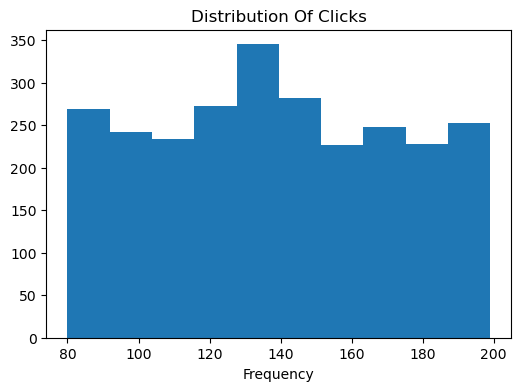

In [52]:
plt.figure(figsize=(6,4))
plt.hist(df['Clicks'])
plt.title('Distribution Of Clicks')
plt.xlabel('Frequency')
plt.show


<h1 style="color:blue;font-size:18px";>Insights</h1>

The distribution of clicks is fairly uniform,with most campaign receving between 80 and 200 clicks .the highest
concetration of clicks is around 130-150,indicating consistent user engagement across campaigns without significant outliers.

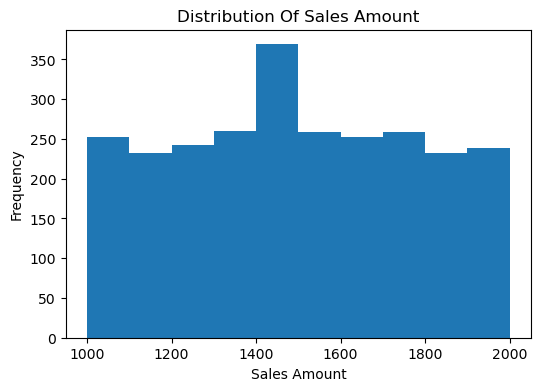

In [53]:
#Histogram of sales

plt.figure(figsize=(6,4))
plt.hist(df['Sale_Amount'])
plt.title('Distribution Of Sales Amount')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.show()




<h1 style="color:blue;font-size:18px";>Insight</h1>



The sales amounts are distributed between 1000,and 2000,,with most values concerated in the middle range.
    The distribution is relativel balanced ,indicating stable sales performance across campaigns and the absence of significant outliers
*The sales distribution is highet in the 1400-1600 range.this shows most customer prefer mid-range purchase values
*Very low/high sales range are less frequent compared to middile range.


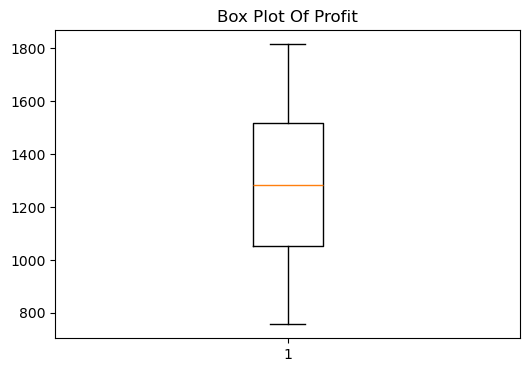

In [54]:
#Box plot of profit:Helps detect unusually high or low profit vallues.

plt.figure(figsize=(6,4))
plt.boxplot(x=df['Profit'])
plt.title('Box Plot Of Profit')
plt.show()

<h1 style="color:blue;font-size:18px";>Insights</h1>

The box plot of profit shows that the median profit is around 1250.Most profit value are concerated between 1000 and 1500.
    The profit range from approximately 750 to 1800,indicating more variablity.No significant outliers are present,
suggesting that the prifit data is fairly consistent and free from extreme values.

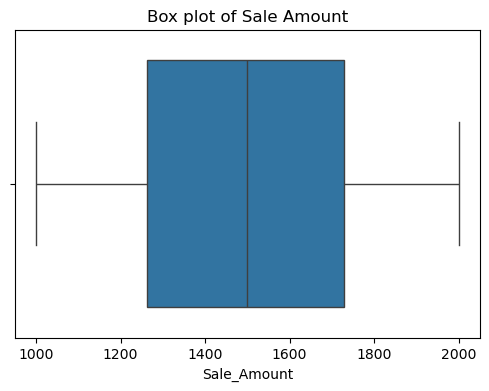

In [55]:
#box plot of Sales Amount:Used to identify outliers in sale data
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sale_Amount'])
plt.title('Box plot of Sale Amount')
plt.show()

<h1 style="color:blue;font-size:18px";> Insights</h1>

In [ ]:
The box plot of Sale Amont shows the median value of appriximatly 1500.Most sales are distributed betwwen 1250 and 1750.The sale amount ranges from about 
1000 to 2000 ,indicating moderate variablity.No significant outliers are present,suggesting a consistant sales distributiion

<h2 style="color:green;font-size:20px";>Bivariate Analysis</h2>

In [56]:
#Groupby:Sales by Campaign
sales_campaign=df.groupby('Campaign_Name')['Sale_Amount'].sum().sort_values(ascending=False)
print(sales_campaign)


Campaign_Name
Data Analytcis Course    1.021021e+06
Data Analytics Corse     9.724390e+05
DataAnalyticsCourse      9.581871e+05
Data Anlytics Corse      9.448377e+05
Name: Sale_Amount, dtype: float64


Explanation:Shows which campaign generated the highest sales.

#Visualizing by Bar chart

<function matplotlib.pyplot.show(close=None, block=None)>

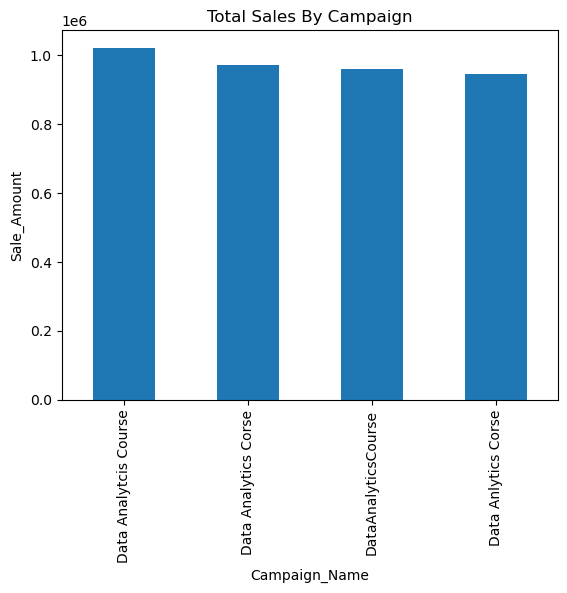

In [57]:
sales_campaign.plot(kind='bar')
plt.title('Total Sales By Campaign')
plt.ylabel('Sale_Amount')
plt.show



<h1 style="color:blue;font-size:18px";>Insights</h1>

Total sales by campaign shows that the Analytics course campaign achieved the maxium sales,indicating it is the top performimg campaigns,while other misalabeled or smaller campaign contribute relatively lower sales.

#Campare the sales performance across the campaign

In [59]:
#Profit by Device
profit_device=df.groupby('Device')['Profit'].sum().sort_values(ascending=False)
print(profit_device)

Device
MOBILE     396490.372270
desktop    393210.851646
tablet     388593.262901
Desktop    387263.146692
TABLET     372148.010451
Mobile     369096.324108
DESKTOP    360744.317315
mobile     358356.067295
Tablet     311347.114230
Name: Profit, dtype: float64


it shows which device generated  the highest profit

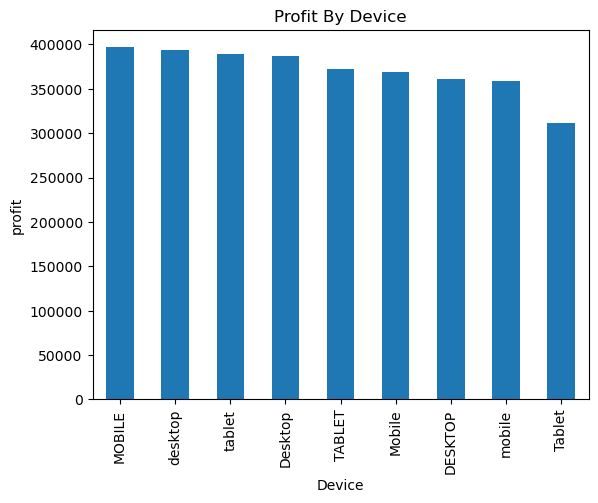

In [60]:
profit_device.plot(kind='bar')
plt.title('Profit By Device')
plt.ylabel('profit')
plt.show()

<h1 style="color:blue;font-size:18px";>Insights</h1>


Profit by device analysis shows that desktop users generate the maximum profit,while tablet users contribute the last.Mobile has the highest usage count but moderate profit,indicating the mobile traffic is gigh but conversion value is lower compared to desktop.

<h2 style ="color:green;font-size:20px";> Multivariate Analysis</h2>

In [61]:
#Pivot Table

pivot_table=df.pivot_table(values='Sale_Amount',index='Campaign_Name',columns='Device',aggfunc='sum')
print(pivot_table)

Device                       DESKTOP        Desktop         MOBILE  \
Campaign_Name                                                        
Data Analytcis Course  105382.296221  123586.240553  129907.296221   
Data Analytics Corse    97660.944332  106449.648111  125230.592442   
Data Anlytics Corse    115299.592442  123747.240553   94021.888663   
DataAnalyticsCourse    101966.240553   99011.944332  113950.240553   

Device                        Mobile         TABLET         Tablet  \
Campaign_Name                                                        
Data Analytcis Course  126369.832995   94582.648111   96286.648111   
Data Analytics Corse   102043.240553  108904.592442  102343.296221   
Data Anlytics Corse     94938.944332  102952.888663   82678.592442   
DataAnalyticsCourse    108982.944332  125287.296221   83681.592442   

Device                       desktop         mobile         tablet  
Campaign_Name                                                       
Data Analytcis Cours

it  shows sales generated by each campaign across different device.


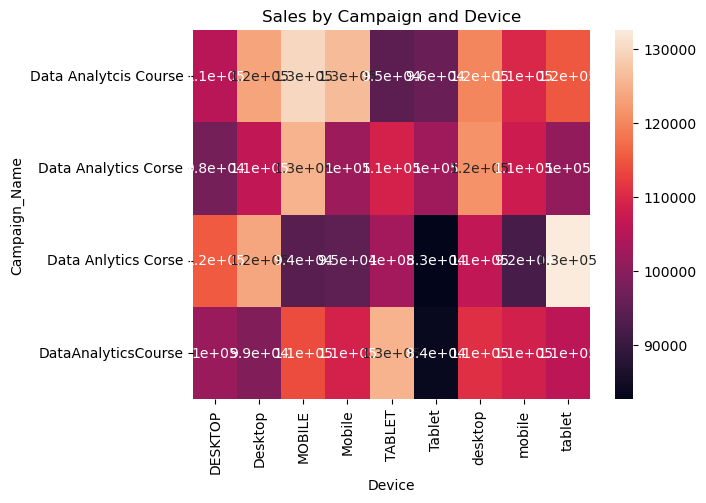

In [62]:
#pivit table visualization
sns.heatmap(pivot_table,annot=True)
plt.title('Sales by Campaign and Device')
plt.show()

<h1 style="color:blue;font-size:18px";>Insights</h1>

In [ ]:
Heatmap of analysis of sales by campaign and device show that Desktop users generate the highest salse across campaigns,while Tablet users 
contribute the least.The analytics course campaign is top performing segment;however,inconsistent campaign accurate interpretation of results.
    

provides a visualcomparison of campaignperformance by device.

# Coreelation Analysis:Mesure relationship between numerical vaiables.

In [64]:
numeric_df=df.select_dtypes(include='number')
correlation=numeric_df.corr()
print(correlation)

                        Clicks  Impressions      Cost     Leads  Conversions  \
Clicks                1.000000     0.001435  0.033187  0.052637     0.006488   
Impressions           0.001435     1.000000  0.000645 -0.034717    -0.013522   
Cost                  0.033187     0.000645  1.000000 -0.009112     0.003791   
Leads                 0.052637    -0.034717 -0.009112  1.000000     0.022857   
Conversions           0.006488    -0.013522  0.003791  0.022857     1.000000   
Conversion Rate      -0.436029     0.013072 -0.005989 -0.011985     0.562911   
Sale_Amount           0.035138    -0.008113  0.010346  0.011561    -0.002928   
CPC                  -0.909384    -0.008854  0.307753 -0.058226     0.004422   
Lead_Conversion_Rate -0.034586     0.016532  0.008289 -0.647076     0.681616   
Profit                0.032714    -0.008145 -0.060815  0.012189    -0.003193   
Year                       NaN          NaN       NaN       NaN          NaN   

                      Conversion Rate  

It shows whether variables move together positively or negatively
*positive value---increase together
*negative value---move in opposite directions 
*near 0         ---weak relationship

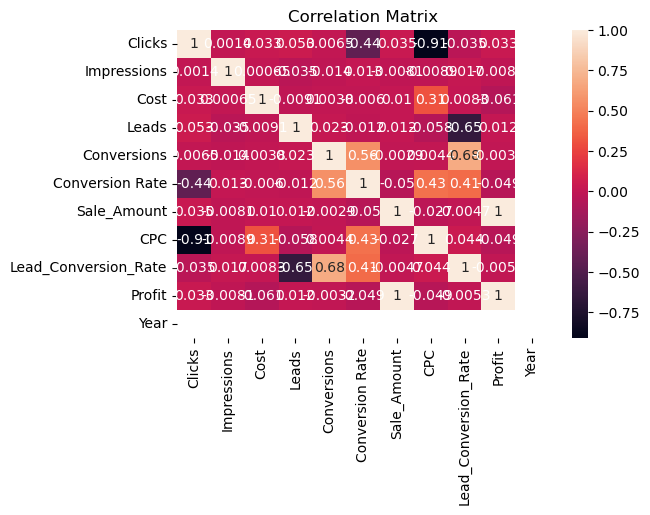

In [65]:
#Corelation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(correlation,annot=True)
plt.title('Correlation Matrix')
plt.show()

<h1 style="color:blue;font-size:18px";>Insights</h1>

In [ ]:
Correlation matrix anatlysis show that clicks and impressions have a strong positive relationship,indicating higher visiblityleadsto more engagement.
Conversions strongly drive both sales amount and profit,making them the key performance indicators.However,higher CPU show a negative impact
on profitablity,suggesting that cost optimization is essential for better ROI.

<h3 sytyle="color:green;font-size:23px;">Findings</h3>

1.Some campaigns generated significantly higer sales than others.
2.Mobile and desktop device contributed differently profits.
3.sale amount and profit showed strong positive relationship.
4.Box plots revealed a few outliers in sale amount and profit.
5.correlation analysis showed that higer clicks generally led to more conversions and sales.

<h3 style="color:red; font-size:24px;">Visualization </h3>;

<h2 style="color:green; font-size:20pz;">Histogram-Distribution Of Clicks</h2>

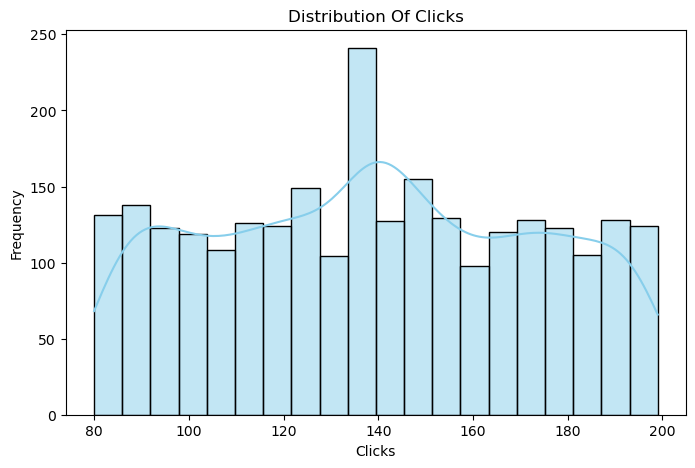

In [66]:
#To understand how clicks are distributed

plt.figure(figsize=(8,5))
sns.histplot(df['Clicks'],bins=20,kde=True,color='skyblue')
plt.title('Distribution Of Clicks')
plt.xlabel('Clicks')
plt.ylabel('Frequency')
plt.show()
    

<h1 style="color:blue; font-size:18px";>Insights</h1>

The click distribution ranges from approximatly 80 to 200clicks.The highest concentration of clicks occurs around 135-140clicks,while the lowest frequencies are found at the extreme ranges.Most campaigns generated between 120 and 160 clicks,indicating a fairly balanced distribution of click
performance.

maximum count value:135-140 clicks
minimum count value:80-90 clicks and 190-200clicks(lowest frequency bins)


<h2 style="color:green; font-sixe:20px";>Histogram- Distribution Of Sales Amonut</h2>

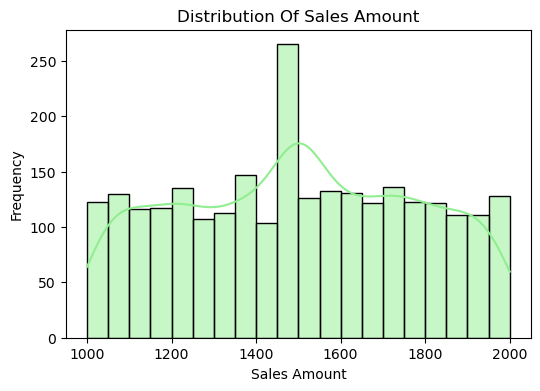

In [67]:
plt.figure(figsize=(6,4))
sns.histplot(df['Sale_Amount'],bins=20,kde=True,color='lightgreen')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.title('Distribution Of Sales Amount')
plt.show()

<h1 style="color:blue; font-size:18px;">Insights</h1>

In [ ]:
The majority of sales amounts are concenrated around 1500,with the highest frequency observed in the 1450-1500 range.Sales value are fairly evenly 
distributed between 1000 and 2000,indicating stable sales performance.

<h2 style="color:green; font-size:20px";>Box Plot(Profit)</h2>

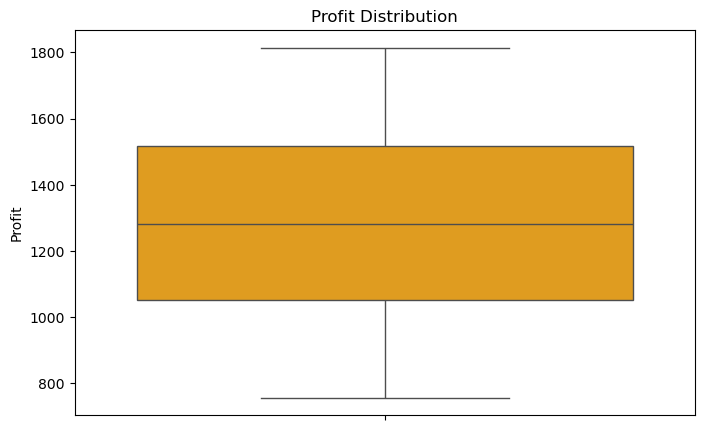

In [68]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Profit'],color='orange')
plt.title('Profit Distribution')
plt.show()

<h1 style="color:blue; font-size:18px";>Insights</h1>

The profit distribution ranges from approximately 750 to 1800,with a meadian profit around 1270.Most profit values are concentrated between 1050 and 1500,and no significant outliers are observed,indicating stable profit performance accross campaigns.

<h2 style="color:green; font-size:20px";>Total Sales By Campaign</h2>

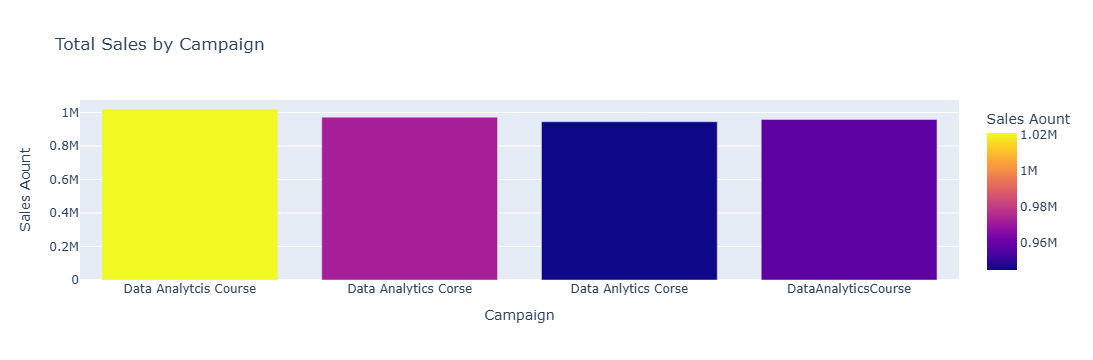

In [69]:
sales_campaign=df.groupby('Campaign_Name')['Sale_Amount'].sum().reset_index()
fig=px.bar(
           sales_campaign,
           x='Campaign_Name',
           y='Sale_Amount',
           color='Sale_Amount',
           title='Total Sales by Campaign',
           labels={
                    'Campaign_Name':'Campaign',
                    'Sale_Amount':'Sales Aount'
           }
)
fig.show()
    
                   

<h1 style='color:blue; font-size:18px';>Insights</h1>

All campaigns generated sales above 1 million.The highest sales were recorded by DataAnalyticsCourse,while the lowest were around 1.05M.The small 
variation in sales indicates consistent and stable campaign performance.

<h2 style="color:green;font-size:20px";>Profit by Device</h2>

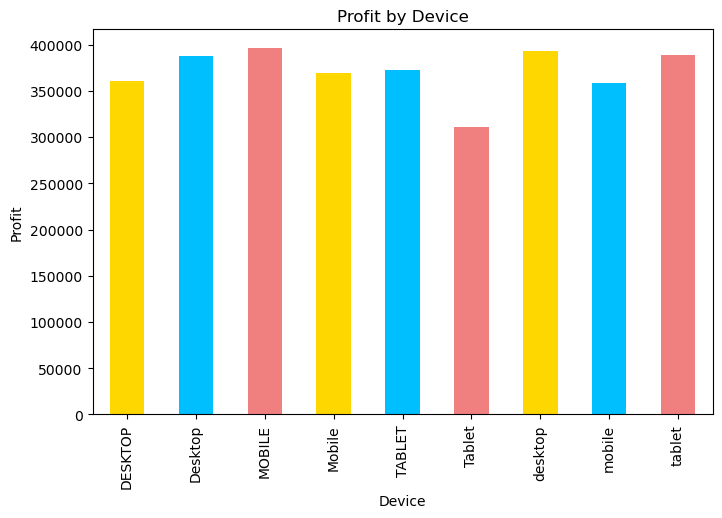

In [70]:
profit_device=df.groupby('Device')['Profit'].sum()
plt.figure(figsize=(8,5))
profit_device.plot(kind='bar',color=['gold','deepskyblue','lightcoral'])
plt.title('Profit by Device')
plt.xlabel('Device')
plt.ylabel('Profit')
plt.show()
                   

<h1 style="color:blue;font-size:18px";>Insights</h1>

Mobile device generated the gighest profit,while Tablet device generated the lowest profit.Most device recorded profit between 320K and 380K,indicating
strong and consistent profit performance across device categories.


<h2 style="color:green;font-size:20px";>Heatmap(Sales by campaign Device)</h2>

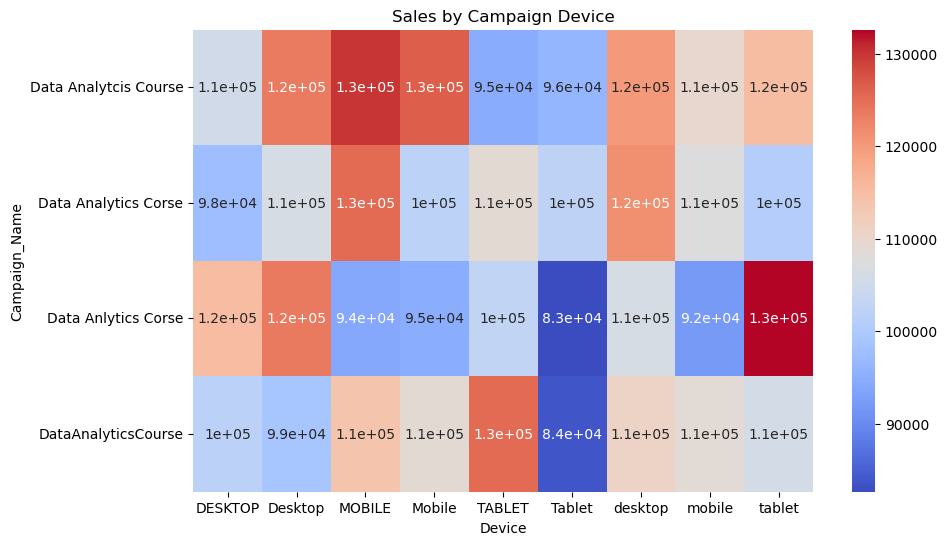

In [71]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot_table,annot=True,cmap='coolwarm')
plt.title('Sales by Campaign Device')
plt.show()
            

<h1 style="color:blue;font-size:18px";>Insights</h1>

In [ ]:
The heatmap shows that sales performance varies across device.Mobile device generally generate higher sales,while tablet device show the greatest
variation and include the lowest sales values.Desktop performance remain stable across the campaign .Therefore,increasing focus on Mobile-targeted
advertising may help maximize overall sales.

<h2 style="color:green;font-size:20px";>Sales Share by Device(Pie Chart)</h2>

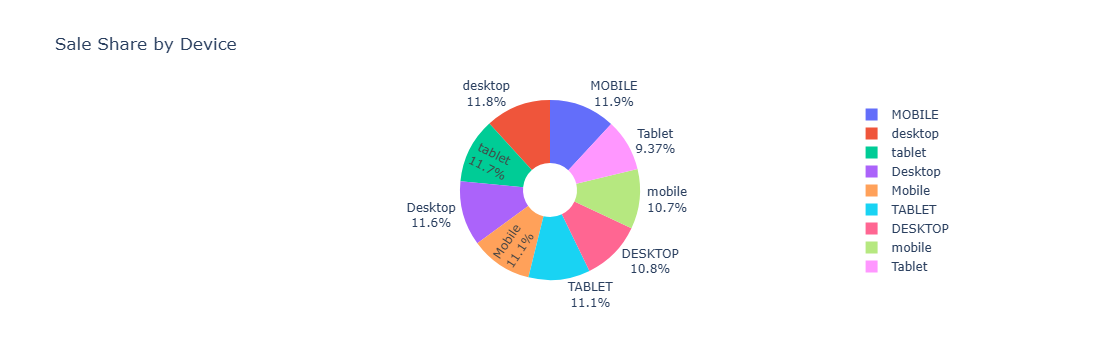

In [72]:
sales_by_device=df.groupby('Device')['Sale_Amount'].sum().reset_index()
fig=px.pie(sales_by_device,values='Sale_Amount',names='Device',title='Sale Share by Device',hole=0.3)
fig.update_traces(textinfo='percent+label')
fig.show()

<h1 style="color:blue;font-size:18px";>Insight</h1>
    

The pie chart show a balanced distribution of sales across device.MOBILE contribures the highest share(11.9%),whilw Tablet contributes the lowest share
(9.3%).Most device categories account for approximately 10-12% of total sales,indicating consistent performance across device.

<h3 style="color:red;font-size:24px";>Insight Generation and Report</h3>

<h2 style="color:green;font-size:20px";>Key insights</h2>

*Most advertisement received a moderate number of clicks,indicating consistent user engagement.
*Sales amounts are concentrated within a common range,with only a few campaigns generating exceptionally high sales.
*Prifit distribution shows variablity across advertisment ,with some outliers indicating highly profitable campaigns.
*Certain campaigns consistently achieved higher sales than others,suggesting stronger campaign performance.
*Device type influnces sale and profit ,with some device performing better than others.
*The heat map revealed that specific campaign device combinations generateed higher sales,highlighting effective targeting opportunities.

<h2 style="color:green;font-size:20px";>Patterns and Observations</h2>

*A positive reletionship exists between clicks,conversions,and sales performance.
*High performing campaigns tend to generate both higher sales and profits.
*Sales distribution is not uniform across device,indicating differences in user behavior
*A few campaigns and advertisements contribute dispropotionately to overall revenue.

<h2 style="color:green;font-size:20px";>Conclusion</h2>

The analysis shows that campaign effectiveness,device type,and user enagagement are key factors influencing sales and profitablity .Business should
focus on high performing campaigns and optimize advertising strategies for the most profitable device.Further analysis can be conducted on kwywords,locations,and customer segments to improve campaign performance and maximize return on inverstment.